In [3]:
!pip install pandas praw yfinance vaderSentiment matplotlib

In [4]:
import pandas as pd
import praw
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [5]:
REDDIT_CLIENT_ID = "Hwp356Li2a5b5LskAit42g"
REDDIT_CLIENT_SECRET = "KotH4RuAN0gj2_1ApR-vHEuGcb2Q_g"
REDDIT_USER_AGENT = "GoQuantAssignment v1.0 by Vivid_Will_2059"

TARGET_TICKER = 'BTC-USD'
TARGET_SUBREDDIT = 'CryptoCurrency'
DATA_PERIOD = '3mo'
POST_LIMIT = 500

In [6]:
def fetch_reddit_data(subreddit_name, limit):
    """Fetches post titles and text from a subreddit."""
    print(f"🔥 Fetching latest {limit} posts from r/{subreddit_name}...")
    try:
        reddit = praw.Reddit(
            client_id=REDDIT_CLIENT_ID,
            client_secret=REDDIT_CLIENT_SECRET,
            user_agent=REDDIT_USER_AGENT
        )
        posts_data = []
        subreddit = reddit.subreddit(subreddit_name)
        for post in subreddit.hot(limit=limit):
            posts_data.append({
                'timestamp': pd.to_datetime(post.created_utc, unit='s'),
                'title': post.title,
                'text': post.selftext
            })
        df = pd.DataFrame(posts_data)
        df.set_index('timestamp', inplace=True)
        print(f"✅ Successfully fetched {len(df)} posts.")
        return df
    except Exception as e:
        print(f"❌ Error fetching from Reddit: {e}")
        return pd.DataFrame()

def fetch_financial_data(ticker, period):
    """Fetches historical market data for a given ticker from Yahoo Finance."""
    print(f"📈 Fetching {period} of market data for {ticker}...")
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period, interval='1d')
        df.index = df.index.tz_localize(None)
        print(f"✅ Successfully fetched {len(df)} days of price data.")
        return df
    except Exception as e:
        print(f"❌ Error fetching from Yahoo Finance: {e}")
        return pd.DataFrame()

In [7]:
def analyze_sentiment(df):
    print("🧠 Analyzing sentiment of Reddit posts...")
    analyzer = SentimentIntensityAnalyzer()
    df['full_text'] = df['title'] + ' ' + df['text']
    df['sentiment'] = df['full_text'].apply(lambda text: analyzer.polarity_scores(text)['compound'])
    print("✅ Sentiment analysis complete.")
    return df

In [8]:
def generate_signals_and_correlate(reddit_df, financial_df):
    if reddit_df.empty or financial_df.empty:
        return None

    print("🔗 Aggregating sentiment and merging with financial data...")
    daily_sentiment = reddit_df['sentiment'].resample('D').mean().to_frame(name='avg_sentiment')
    daily_sentiment.ffill(inplace=True)

    combined_df = financial_df.join(daily_sentiment, how='inner')

    print("💡 Generating Fear & Greed signals...")
    short_window = 5
    long_window = 15
    combined_df['sentiment_short_ma'] = combined_df['avg_sentiment'].rolling(window=short_window, min_periods=1).mean()
    combined_df['sentiment_long_ma'] = combined_df['avg_sentiment'].rolling(window=long_window, min_periods=1).mean()

    combined_df['signal'] = 0
    combined_df.loc[combined_df['sentiment_short_ma'] > combined_df['sentiment_long_ma'], 'signal'] = 1  # Greed
    combined_df.loc[combined_df['sentiment_short_ma'] < combined_df['sentiment_long_ma'], 'signal'] = -1 # Fear
    combined_df['trade_signal'] = combined_df['signal'].diff()

    print("✅ Signal generation complete.")
    return combined_df

In [9]:
def plot_results(df):
    if df is None or df.empty:
        print("❌ No data to plot.")
        return

    print("📊 Generating plot...")
    fig, ax1 = plt.subplots(figsize=(18, 9), dpi=100)

    ax1.set_title(f"Sentiment & Trade Signals for {TARGET_TICKER}", fontsize=20)
    ax1.plot(df.index, df['Close'], color='skyblue', label='Close Price', linewidth=2)
    ax1.set_ylabel('Close Price (USD)', color='skyblue', fontsize=14)
    ax1.grid(True, which='major', linestyle='--', linewidth=0.5)

    buy_signals = df[df['trade_signal'] > 0]
    ax1.plot(buy_signals.index, buy_signals['Close'], '^', markersize=12, color='green', label='Buy Signal (Fear)')

    sell_signals = df[df['trade_signal'] < 0]
    ax1.plot(sell_signals.index, sell_signals['Close'], 'v', markersize=12, color='red', label='Sell Signal (Greed)')

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['sentiment_short_ma'], color='orange', label='Sentiment (Greed Proxy)')
    ax2.plot(df.index, df['sentiment_long_ma'], color='purple', label='Sentiment (Fear Proxy)')
    ax2.set_ylabel('Sentiment Score', color='gray', fontsize=14)
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)

    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.show()

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Starting Fear & Greed Engine for BTC-USD
🔥 Fetching latest 500 posts from r/CryptoCurrency...


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



✅ Successfully fetched 340 posts.
📈 Fetching 3mo of market data for BTC-USD...
✅ Successfully fetched 92 days of price data.
🧠 Analyzing sentiment of Reddit posts...
✅ Sentiment analysis complete.
🔗 Aggregating sentiment and merging with financial data...
💡 Generating Fear & Greed signals...
✅ Signal generation complete.

--- Final Data Sample ---
                    Close  avg_sentiment  signal  trade_signal
2025-07-09  111326.554688       0.127233       0           NaN
2025-07-10  115987.203125       0.190180       0           0.0
2025-07-11  117516.992188       0.151193       0           0.0
2025-07-12  117435.226562       0.173005       0           0.0
2025-07-13  119116.117188       0.249432       0           0.0
2025-07-14  119849.703125       0.217678       1           1.0
2025-07-15  117777.187500       0.287006       1           0.0
2025-07-16  118173.554688       0.149617       1           0.0
📊 Generating plot...


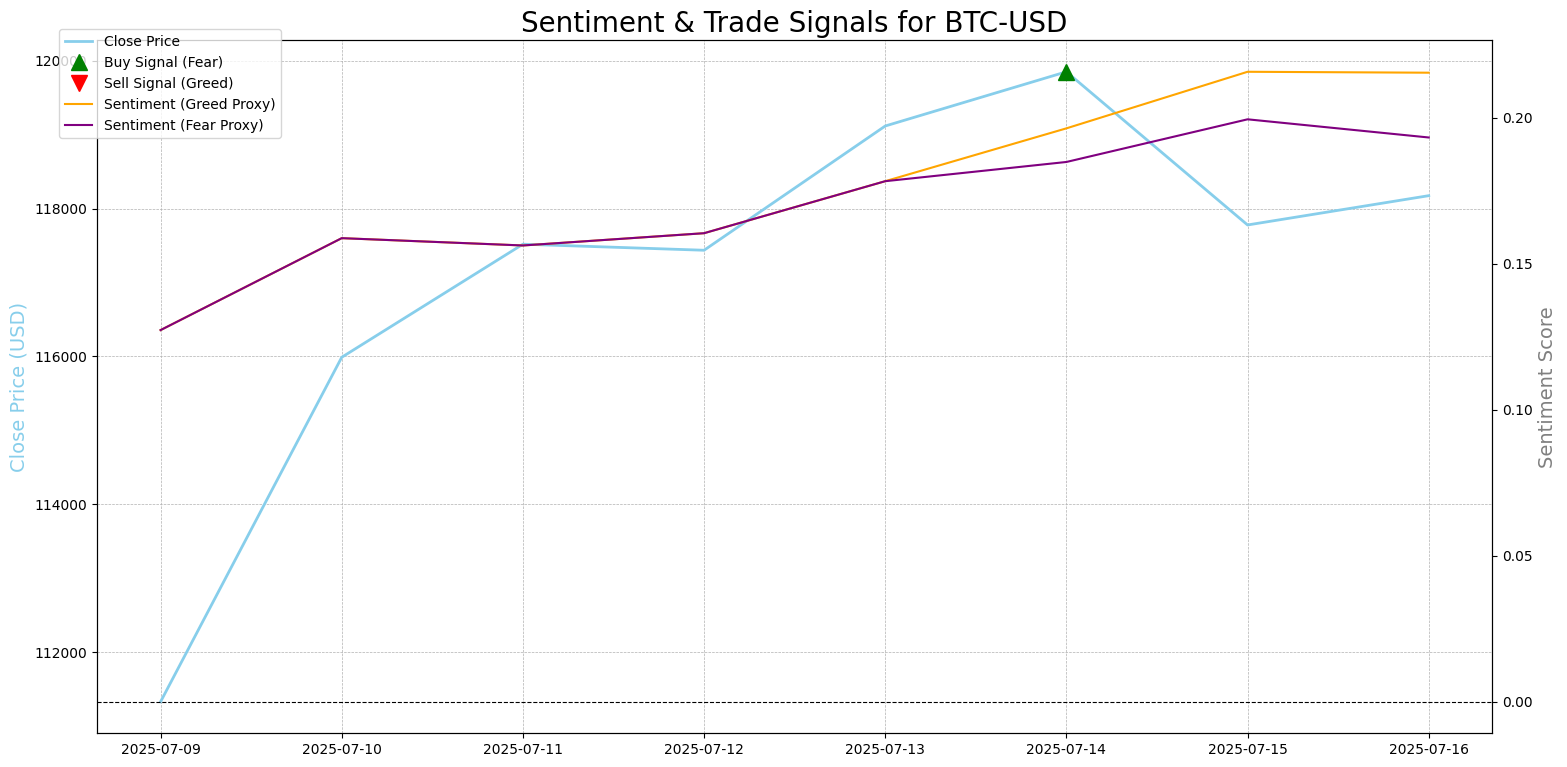


✅ Pipeline execution finished.


In [10]:
def run_pipeline():
    print("==================================================")
    print(f"Starting Fear & Greed Engine for {TARGET_TICKER}")
    print("==================================================")

    reddit_data = fetch_reddit_data(TARGET_SUBREDDIT, POST_LIMIT)
    financial_data = fetch_financial_data(TARGET_TICKER, DATA_PERIOD)

    if not reddit_data.empty:
        sentiment_data = analyze_sentiment(reddit_data)
        final_df = generate_signals_and_correlate(sentiment_data, financial_data)

        if final_df is not None:
            print("\n--- Final Data Sample ---")
            print(final_df[['Close', 'avg_sentiment', 'signal', 'trade_signal']].tail(10))
            plot_results(final_df)

    print("\n✅ Pipeline execution finished.")

run_pipeline()